In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub

/kaggle/input/datasets/pmahato/register-less/train_clean.csv
/kaggle/input/datasets/pmahato/register-less/test_clean.csv
/kaggle/input/datasets/pmahato/register-less/val_clean.csv


In [2]:
!pip install -q transformers datasets evaluate accelerate statsmodels

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 2.0 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.2/12.2 MB 101.6 MB/s eta 0:00:0000:010:01
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
dask-cuda 26.2.0 requires cuda-core==0.3.*, but you have cuda-core 1.0.1 which is incompatible.
dask-cuda 26.2.0 requires numba-cuda<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
distributed-ucxx-cu12 0.48.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
cuml-cu12 26.2.0 requires numba<0.62.0,>=0.60.0, but you have numba 0.65.1 which is incompatible.
cuml-cu12 26.2.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
ucxx-cu12 0.48.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompa

In [3]:
import numpy as np
import pandas as pd
import torch
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, f1_score, accuracy_score


train_df = pd.read_csv('/kaggle/input/datasets/pmahato/register-less/train_clean.csv')
val_df = pd.read_csv('/kaggle/input/datasets/pmahato/register-less/val_clean.csv')
test_df = pd.read_csv('/kaggle/input/datasets/pmahato/register-less/test_clean.csv')

print("Train:", train_df.shape, "Val:", val_df.shape, "Test:", test_df.shape)
print("Classes:", train_df['Label'].nunique())

label_encoder = LabelEncoder()
label_encoder.fit(train_df['Label'])
num_labels = len(label_encoder.classes_)
print("num_labels:", num_labels)

train_df['label_id'] = label_encoder.transform(train_df['Label'])
val_df['label_id'] = label_encoder.transform(val_df['Label'])
test_df['label_id'] = label_encoder.transform(test_df['Label'])

Train: (14928, 2) Val: (2635, 2) Test: (2207, 2)
Classes: 24
num_labels: 24


In [4]:
print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
    print("GPU count:", torch.cuda.device_count())

SEEDS = [42, 123, 2024]

CUDA available: True
GPU: Tesla T4
GPU count: 2


In [5]:
# Document length sanity check -- motivates the DistilBERT vs Longformer comparison directly
word_counts = train_df['Text'].str.split().str.len()
print(f"\nDocument length (words): mean={word_counts.mean():.0f}, median={word_counts.median():.0f}, "
      f"95th pct={word_counts.quantile(0.95):.0f}, max={word_counts.max()}")
print(f"Fraction of docs over 512 'words' (proxy for exceeding DistilBERT's token budget): "
      f"{(word_counts > 400).mean():.2%}")
print(f"Fraction of docs over 3000 'words' (proxy for exceeding Longformer's 4096-token budget): "
      f"{(word_counts > 3000).mean():.2%}")



Document length (words): mean=1157, median=590, 95th pct=3537, max=109833
Fraction of docs over 512 'words' (proxy for exceeding DistilBERT's token budget): 66.49%
Fraction of docs over 3000 'words' (proxy for exceeding Longformer's 4096-token budget): 6.36%


In [6]:
from sklearn.utils.class_weight import compute_class_weight

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.arange(num_labels),
    y=train_df['label_id'].values
)
class_weights_t = torch.tensor(class_weights, dtype=torch.float)
print(class_weights_t)


tensor([ 3.2910,  0.5770,  3.4365,  1.5171,  0.6603,  2.2455,  9.5692,  5.0569,
         1.2490,  3.0945,  3.7927,  0.1312,  0.5065,  0.6086, 19.4375,  1.1476,
         2.4880,  8.1842,  2.2701,  0.9120,  1.9809,  0.4278,  5.6545,  8.1842])


---
# Phase A: TF-IDF + Linear SVM baseline

Fast (~5 min, CPU). Word unigrams + bigrams, sublinear TF scaling,
`class_weight='balanced'` to address residual class imbalance.
Classical linear models have negligible training-run variance, so a single
run is standard practice — stated explicitly in the writeup.

Documents truncated at 2000 words purely to stay within memory; this matches
a conservative upper bound on what a non-transformer model can meaningfully
use from a single web document and is noted as a practical constraint.

In [7]:
!pip install -q transformers accelerate statsmodels

In [8]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC

def truncate(texts, max_words=2000):
    return [' '.join(str(t).split()[:max_words]) for t in texts]

X_train_raw = truncate(train_df['Text'].values)
X_val_raw   = truncate(val_df['Text'].values)
X_test_raw  = truncate(test_df['Text'].values)

print("Fitting TF-IDF vectorizer...")
vec = TfidfVectorizer(
    analyzer='word', ngram_range=(1, 2), min_df=3, max_df=0.9,
    sublinear_tf=True, max_features=30000
)
X_train_vec = vec.fit_transform(X_train_raw)
X_val_vec   = vec.transform(X_val_raw)
X_test_vec  = vec.transform(X_test_raw)
print(f"Feature matrix: {X_train_vec.shape}")

print("Training LinearSVC...")
clf = LinearSVC(class_weight='balanced', max_iter=5000, random_state=42)
clf.fit(X_train_vec, train_df['Label'].values)
print("Done.")


Fitting TF-IDF vectorizer...
Feature matrix: (14928, 30000)
Training LinearSVC...
Done.


In [9]:
val_pred  = clf.predict(X_val_vec)
test_pred = clf.predict(X_test_vec)

svm_val_acc    = accuracy_score(val_df['Label'].values, val_pred)
svm_val_f1     = f1_score(val_df['Label'].values, val_pred, average='macro', zero_division=0)
svm_test_acc   = accuracy_score(test_df['Label'].values, test_pred)
svm_test_f1    = f1_score(test_df['Label'].values, test_pred, average='macro', zero_division=0)

print(f"SVM val   accuracy={svm_val_acc:.4f}  macro-F1={svm_val_f1:.4f}")
print(f"SVM test  accuracy={svm_test_acc:.4f}  macro-F1={svm_test_f1:.4f}")
print()
print(classification_report(test_df['Label'].values, test_pred, zero_division=0))

# Bootstrap CI on test macro-F1
rng = np.random.RandomState(42)
n = len(test_df)
boot_f1 = [f1_score(test_df['Label'].values[idx := rng.randint(0,n,n)],
                    test_pred[idx], average='macro', zero_division=0)
           for _ in range(2000)]
svm_ci = (float(np.percentile(boot_f1, 2.5)), float(np.percentile(boot_f1, 97.5)))
print(f"Bootstrap 95% CI for test macro-F1: [{svm_ci[0]:.4f}, {svm_ci[1]:.4f}]")

# Save predictions — needed for paired McNemar's tests later
svm_pred_df = pd.DataFrame({
    'text': test_df['Text'].values,
    'y_true': test_df['Label'].values,
    'y_pred': test_pred,
})
svm_pred_df.to_csv('svm_test_predictions.csv', index=False)
print("\nSaved svm_test_predictions.csv -- Phase A complete.")


SVM val   accuracy=0.7381  macro-F1=0.6366
SVM test  accuracy=0.7195  macro-F1=0.6223

              precision    recall  f1-score   support

 __label__av       0.31      0.32      0.32        31
 __label__df       0.80      0.76      0.78       180
 __label__dp       0.61      0.47      0.53        30
 __label__ds       0.65      0.65      0.65        69
 __label__dt       0.54      0.55      0.55       150
 __label__en       0.86      0.70      0.77        46
 __label__fi       0.43      0.30      0.35        10
 __label__ha       0.88      0.70      0.78        20
 __label__ht       0.62      0.76      0.68        83
 __label__ib       0.22      0.06      0.10        33
 __label__it       0.77      0.74      0.75        27
 __label__ne       0.87      0.74      0.80       614
 __label__ob       0.55      0.51      0.52       188
 __label__pb       0.52      0.70      0.60       138
 __label__po       0.00      0.00      0.00         5
 __label__qa       0.72      0.73      0.72     

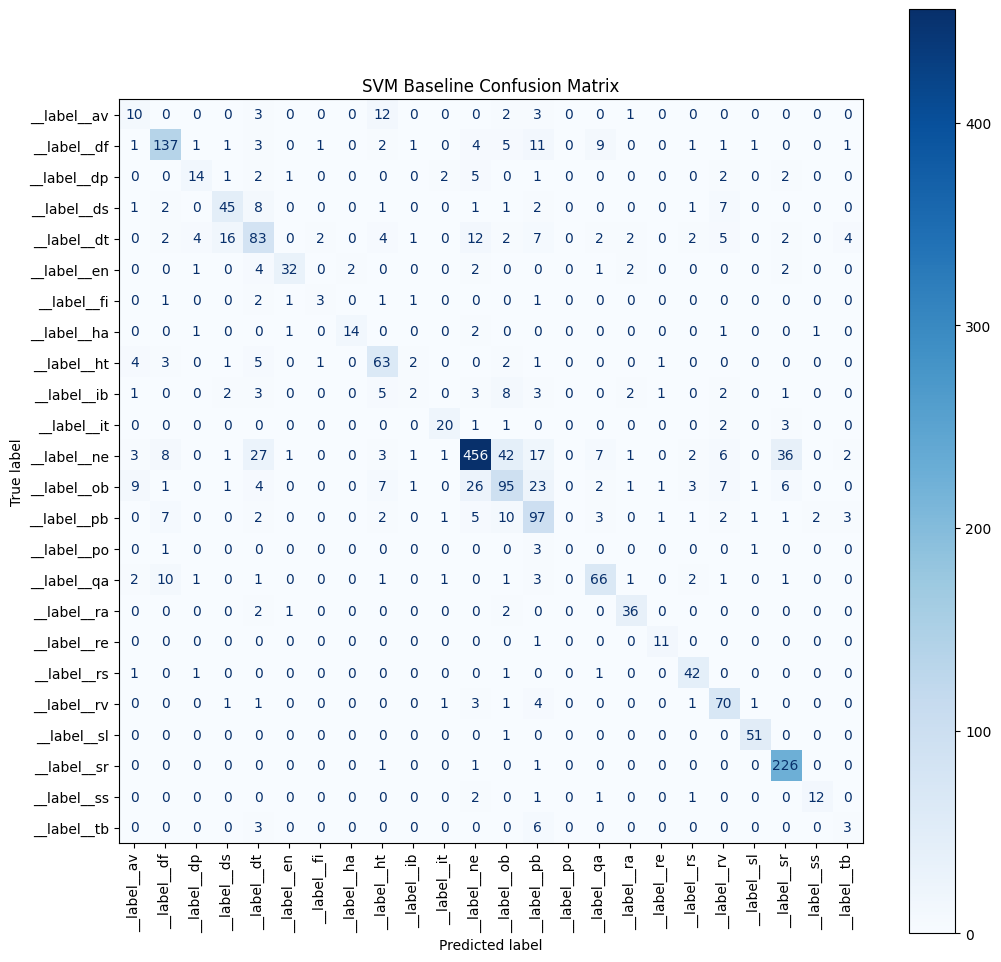

In [10]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Compute the confusion matrix
cm = confusion_matrix(test_df['Label'].values, test_pred, labels=clf.classes_)

# Plot the confusion matrix
fig, ax = plt.subplots(figsize=(12, 12))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=clf.classes_)
disp.plot(cmap='Blues', ax=ax, xticks_rotation='vertical')

plt.title("SVM Baseline Confusion Matrix")
plt.show()

### Overall Performance & Major Confusion Hubs

* **The "General" Category Sinkhole (`__label__ne`):** The model heavily relies on the most frequent class, `__label__ne`, as a catch-all. It incorrectly misclassifies a substantial number of documents from rarer classes into this category (e.g., **27** instances of `__label__dt`, **42** of `__label__ob`, and **36** of `__label__sr` were falsely predicted as `__label__ne`).
* **Strong True Positive Clusters:** The darkest diagonal blocks indicate areas where the baseline handles classification exceptionally well. Notably, `__label__sr` (**226** correct predictions) and `__label__df` (**137** correct predictions) demonstrate strong distinctiveness, showing that their vocabulary profiles are highly separable even for a simple TF-IDF vectorizer.

### Specific Inter-Class Misclassifications

* **`__label__dt` vs. `__label__ds` :** There is noticeable cross-talk between these labels. For instance, **16** documents actually belonging to `__label__dt` were misclassified as `__label__ds`.
* **`__label__ob` vs. `__label__pb`:** A prominent off-diagonal cluster shows that **23** instances of `__label__ob` were mistakenly predicted as `__label__pb`,  This indicates a high level of semantic or vocabulary overlap between these specific categories.
* **Low-Resource Failure (`__label__po`):** The class `__label__po` failed to get a single correct prediction (0 recall), with 3 of its 5 total test instances being misclassified under `__label__pb`.

In [14]:
# Print the exact test set ground truth distribution
print(test_df['Label'].value_counts())

Label
__label__ne    614
__label__sr    229
__label__ob    188
__label__df    180
__label__dt    150
__label__pb    138
__label__qa     91
__label__rv     83
__label__ht     83
__label__ds     69
__label__sl     52
__label__en     46
__label__rs     46
__label__ra     41
__label__ib     33
__label__av     31
__label__dp     30
__label__it     27
__label__ha     20
__label__ss     17
__label__re     12
__label__tb     12
__label__fi     10
__label__po      5
Name: count, dtype: int64


## Expanded Conclusions from the Confusion Matrix

Looking closer at the alignment between the classification report numbers and the visualization blocks, we can draw a few more actionable conclusions for the next model iteration (DistilBERT/Longformer):

### 1. Structural Class Imbalance Imprint

Despite using `class_weight='balanced'`, the model's performance is still tethered to original class frequencies. High-support classes like `__label__ne` (614 instances) and `__label__sr` (229 instances) exhibit strong F1-scores ($0.87$ and $0.81$). Conversely, low-support classes like `__label__fi` (10 instances) and `__label__tb` (12 instances) struggle heavily with macro metrics ($0.35$ and $0.24$ F1). The linear boundary simply lacks enough sparse feature vectors to map the minority classes cleanly.

### 2. The "Formal vs. Practical" Document Overlap

There is a clear vocabulary spillover in how the TF-IDF vectorizer handles legal and structural text:

* **`__label__dt`** (often used for administrative or detail-heavy text) loses **16 items** to **`__label__ds`**.
* This suggests that raw word unigrams and bigrams are failing to capture structural context. The model is latching onto surface-level professional vocabulary rather than the actual document format or register intent.

### 3. Precision vs. Recall Discrepancies

* **High Precision / Low Recall (`__label__ib`):** `__label__ib` has a precision of $0.22$ but a dismal recall of $0.06$. The model is incredibly conservative when predicting this class—it almost never guesses it, and when it does, it's usually wrong anyway.
* **Low Precision / High Recall (`__label__pb`):** `__label__pb` achieves a decent recall of $0.70$ but a lower precision of $0.52$. This means the baseline is over-identifying documents as `__label__pb`, pulling in false positives from classes like `__label__ob` and `__label__df`.

### 🚀 Transition to Phase B (DistilBERT)

These specific patterns strongly justify moving toward a transformer baseline. Because TF-IDF ignores word order and semantic context, it cannot separate classes that share professional jargon (like `__label__dt`, `__label__ds`, and `__label__df`). DistilBERT's contextual embeddings should theoretically help resolve these localized off-diagonal confusions.

---
# Phase B: DistilBERT (3 seeds, max_length=512)

Fast, reliable, but truncates most documents heavily (median doc length far
exceeds 512 tokens). Run this first to bank a complete result.

In [11]:
from torch.utils.data import Dataset
gradient_checkpointing = True

class RegisterDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_length):
        self.texts = list(texts)
        self.labels = list(labels)
        self.tokenizer = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        enc = self.tokenizer(
            str(self.texts[idx]), truncation=True, padding='max_length',
            max_length=self.max_length, return_tensors='pt'
        )
        item = {k: v.squeeze(0) for k, v in enc.items()}
        item['labels'] = torch.tensor(self.labels[idx], dtype=torch.long)
        return item
        # Add global attention mask for Longformer
        if "longformer" in self.tokenizer.name_or_path.lower():
            global_attention_mask = torch.zeros_like(item['input_ids'])
            global_attention_mask[0] = 1  # Global attention on the [CLS] / <s> token
            item['global_attention_mask'] = global_attention_mask

In [26]:
from transformers import Trainer, TrainingArguments
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score

import torch.nn as nn

class WeightedTrainer(Trainer):
    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels = inputs.pop("labels")
        
        # Handle DataParallel multi-GPU wrapping safely
        if isinstance(model, torch.nn.DataParallel):
            outputs = model.module(**inputs)
        else:
            outputs = model(**inputs)
            
        logits = outputs.logits
        loss_fct = nn.CrossEntropyLoss(weight=class_weights_t.to(logits.device))
        loss = loss_fct(logits, labels)
        
        return (loss, outputs) if return_outputs else loss


def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    
    # Calculate metrics with zero_division safety
    accuracy = accuracy_score(labels, preds)
    macro_f1 = f1_score(labels, preds, average='macro', zero_division=0)
    weighted_f1 = f1_score(labels, preds, average='weighted', zero_division=0)
    macro_precision = precision_score(labels, preds, average='macro', zero_division=0)
    macro_recall = recall_score(labels, preds, average='macro', zero_division=0)
    
    return {
        'accuracy': accuracy,
        'macro_f1': macro_f1,
        'weighted_f1': weighted_f1,
        'macro_precision': macro_precision,
        'macro_recall': macro_recall
    }

def run_seeds_for_model(model_name, max_length, seeds, batch_size, grad_accum, epochs=4, lr=2e-5):
    """Trains `model_name` across `seeds`, returns (seed_results list, dict seed->test_preds, test_labels_str)."""
    from transformers import AutoTokenizer, AutoModelForSequenceClassification

    tokenizer = AutoTokenizer.from_pretrained(model_name)
    train_ds = RegisterDataset(train_df['Text'], train_df['label_id'], tokenizer, max_length)
    val_ds = RegisterDataset(val_df['Text'], val_df['label_id'], tokenizer, max_length)
    test_ds = RegisterDataset(test_df['Text'], test_df['label_id'], tokenizer, max_length)

    seed_results = []
    seed_test_preds = {}
    test_labels_str_final = None

    for seed in seeds:
        print(f"\n========== {model_name} | SEED {seed} ==========")
        torch.manual_seed(seed)
        np.random.seed(seed)

        saved_model_path = f'/kaggle/working/{model_name.replace("/", "_")}_seed{seed}'
        model = AutoModelForSequenceClassification.from_pretrained(model_name, num_labels=num_labels)
        #model = AutoModelForSequenceClassification.from_pretrained(saved_model_path, num_labels=num_labels)

        training_args = TrainingArguments(
            output_dir=f'./{model_name.replace("/", "_")}_seed{seed}',
            num_train_epochs=epochs,
            per_device_train_batch_size=batch_size,
            per_device_eval_batch_size=max(batch_size * 2, 4),
            gradient_accumulation_steps=grad_accum,
            learning_rate=lr,
            weight_decay=0.01,
            warmup_ratio=0.1,
            eval_strategy='epoch',
            save_strategy='epoch',
            save_total_limit=1,
            load_best_model_at_end=True,
            metric_for_best_model='macro_f1',
            greater_is_better=True,
            logging_steps=100,
            fp16=torch.cuda.is_available(),
            report_to='none',
            seed=seed,
        # --- CRITICAL FIXES FOR LONGFORMER DATA-PARALLEL ACCELERATION ---
            #no_cuda=False,                     # Keep GPU training active
            dataloader_num_workers=0,          # Prevent multi-threading pipeline lockups
            gradient_checkpointing=True,       # Vital to prevent OOM errors at 2048 tokens
            #ddp_find_unused_parameters=False,
        )

        trainer = WeightedTrainer(
            model=model, args=training_args,
            train_dataset=train_ds, eval_dataset=val_ds,
            compute_metrics=compute_metrics,
        )
        #trainer.train(resume_from_checkpoint=True)
        trainer.train()

        test_output = trainer.predict(test_ds)
        test_preds_id = np.argmax(test_output.predictions, axis=-1)
        test_labels_id = test_output.label_ids
        
        test_preds = label_encoder.inverse_transform(test_preds_id)
        # Generate the ground truth string array directly right here
        test_labels_str = label_encoder.inverse_transform(test_labels_id)
        
        acc = accuracy_score(test_labels_str, test_preds)
        macro_f1 = f1_score(test_labels_str, test_preds, average='macro', zero_division=0)
        weighted_f1 = f1_score(test_labels_str, test_preds, average='weighted', zero_division=0)
        macro_prec = precision_score(test_labels_str, test_preds, average='macro', zero_division=0)
        macro_rec = recall_score(test_labels_str, test_preds, average='macro', zero_division=0)
        
        print(f"Seed {seed} -> test accuracy: {acc:.4f}, test macro-F1: {macro_f1:.4f}")

        # 1. SAVE THE PREDICTIONS TO THE DICTIONARY (Fixes the KeyError)
        seed_test_preds[seed] = test_preds

        # 2. SAVE THE TRUE LABELS STRINGS (So downstream code has access to them)
        test_labels_str_final = test_labels_str
        
        # UPDATE THIS DICTIONARY TO STORE THEM:
        seed_results.append({
            'seed': seed, 
            'test_accuracy': float(acc), 
            'test_macro_f1': float(macro_f1),
            'test_weighted_f1': float(weighted_f1),
            'test_macro_precision': float(macro_prec),
            'test_macro_recall': float(macro_rec)
        })

        del model, trainer
        torch.cuda.empty_cache()

    return seed_results, seed_test_preds, test_labels_str_final


def pick_representative_seed(seed_results):
    """Median-F1 seed, not best -- avoids cherry-picking the strongest run for paired tests."""
    df = pd.DataFrame(seed_results)
    median_idx = df['test_macro_f1'].sort_values().index[len(df) // 2]
    return int(df.loc[median_idx, 'seed'])


In [13]:
distilbert_seed_results, distilbert_seed_preds, test_labels_str = run_seeds_for_model(
    model_name="distilbert-base-uncased",
    max_length=512,
    seeds=SEEDS,
    batch_size=8,
    grad_accum=2,
    epochs=4,
    lr=2e-5,
)

distilbert_df = pd.DataFrame(distilbert_seed_results)
print(distilbert_df)

# Base Metrics
db_acc_mean, db_acc_std = distilbert_df['test_accuracy'].mean(), distilbert_df['test_accuracy'].std()
db_f1_mean, db_f1_std = distilbert_df['test_macro_f1'].mean(), distilbert_df['test_macro_f1'].std()

# New Imbalance Diagnostics
db_weighted_f1_mean, db_weighted_f1_std = distilbert_df['test_weighted_f1'].mean(), distilbert_df['test_weighted_f1'].std()
db_precision_mean, db_precision_std = distilbert_df['test_macro_precision'].mean(), distilbert_df['test_macro_precision'].std()
db_recall_mean, db_recall_std = distilbert_df['test_macro_recall'].mean(), distilbert_df['test_macro_recall'].std()

print(f"\nDistilBERT test accuracy: {db_acc_mean:.4f} +/- {db_acc_std:.4f}")
print(f"DistilBERT test macro-F1: {db_f1_mean:.4f} +/- {db_f1_std:.4f}")
print(f"DistilBERT test weighted-F1: {db_weighted_f1_mean:.4f} +/- {db_weighted_f1_std:.4f}")
print(f"DistilBERT test macro-Precision: {db_precision_mean:.4f} +/- {db_precision_std:.4f}")
print(f"DistilBERT test macro-Recall: {db_recall_mean:.4f} +/- {db_recall_std:.4f}")

distilbert_df.to_csv('distilbert_seed_results.csv', index=False)

distilbert_rep_seed = pick_representative_seed(distilbert_seed_results)
distilbert_rep_preds = distilbert_seed_preds[distilbert_rep_seed]
pd.DataFrame({
    'text': test_df['Text'].values, 'y_true': test_labels_str, 'y_pred': distilbert_rep_preds,
}).to_csv('distilbert_test_predictions.csv', index=False)
print(f"\nRepresentative seed (median F1): {distilbert_rep_seed}")
print("Saved distilbert_seed_results.csv and distilbert_test_predictions.csv -- Phase B result is now banked.")


config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]


========== distilbert-base-uncased | SEED 42 ==========


...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.weight', 'distilbert.embeddings.LayerNorm.bias'].
There were unexpected keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.beta', 'distilbert.embeddings.LayerNorm.gamma'].


Seed 2024 -> test accuracy: 0.7213, test macro-F1: 0.6753
   seed  test_accuracy  test_macro_f1  test_weighted_f1  test_macro_precision  \
0    42       0.725872       0.665539          0.732659              0.646334   
1   123       0.738559       0.662657          0.740741              0.641098   
2  2024       0.721341       0.675325          0.728644              0.652393   

   test_macro_recall  
0           0.713242  
1           0.713183  
2           0.722492  

DistilBERT test accuracy: 0.7286 +/- 0.0089
DistilBERT test macro-F1: 0.6678 +/- 0.0066
DistilBERT test weighted-F1: 0.7340 +/- 0.0062
DistilBERT test macro-Precision: 0.6466 +/- 0.0057
DistilBERT test macro-Recall: 0.7163 +/- 0.0054

Representative seed (median F1): 42
Saved distilbert_seed_results.csv and distilbert_test_predictions.csv -- Phase B result is now banked.


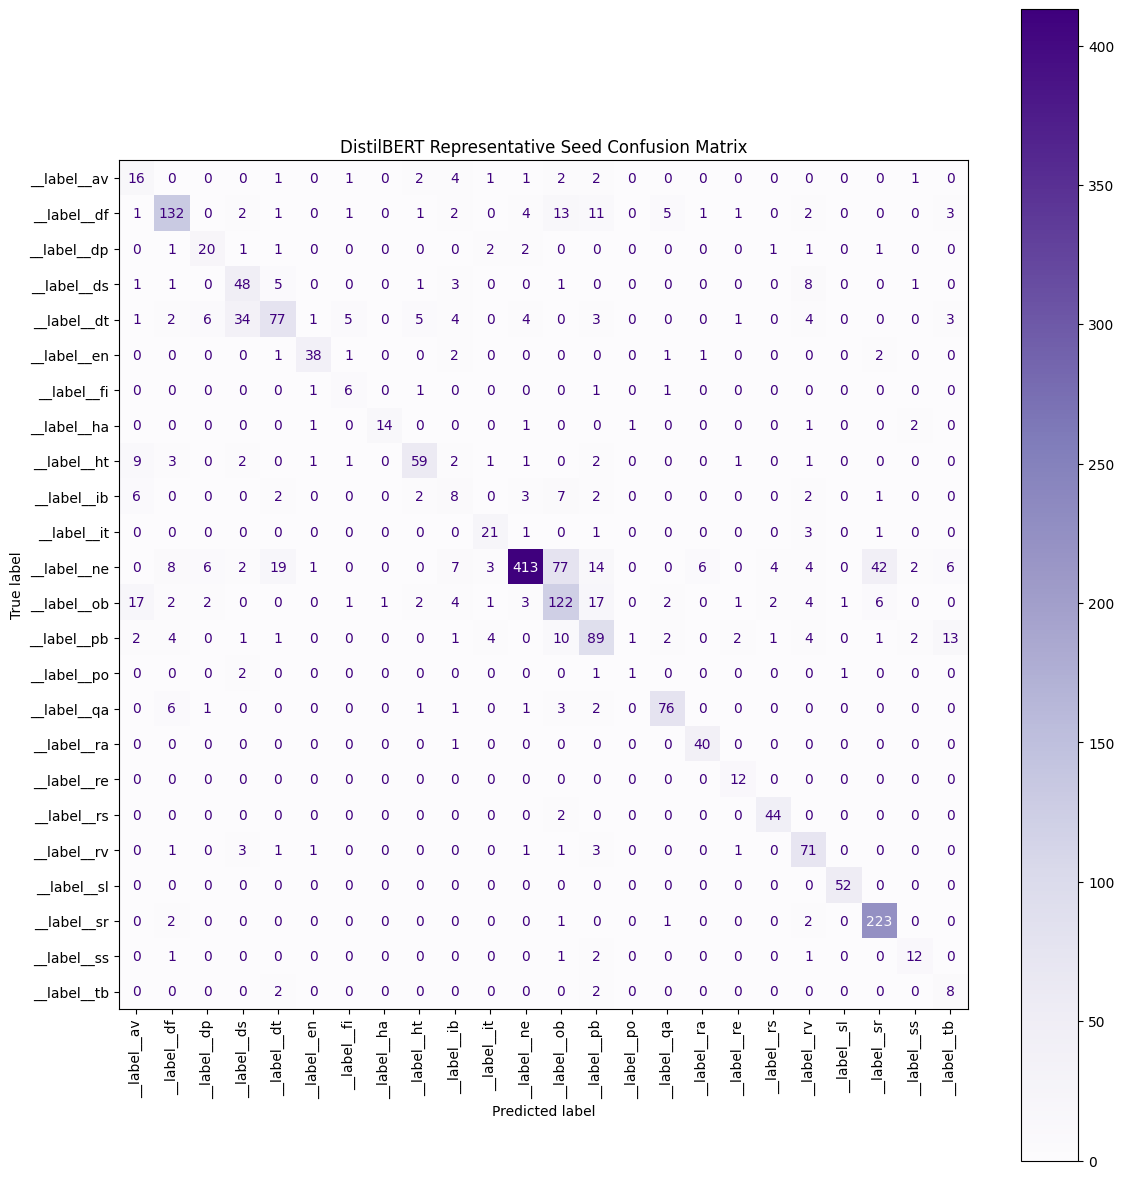

In [31]:
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# 1. Load the banked DistilBERT predictions
distilbert_pred_df = pd.read_csv('distilbert_test_predictions.csv')

y_true = distilbert_pred_df['y_true'].values
y_pred = distilbert_pred_df['y_pred'].values

# 2. Get the unique sorted classes to match your SVM layout
classes = sorted(list(set(y_true)))

# 3. Compute and plot the matrix
cm = confusion_matrix(y_true, y_pred, labels=classes)

fig, ax = plt.subplots(figsize=(12, 12))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=classes)
disp.plot(cmap='Purples', ax=ax, xticks_rotation='vertical')

plt.title("DistilBERT Representative Seed Confusion Matrix")
plt.tight_layout()
plt.show()

---

## 📊 Comparative Analysis: SVM Baseline vs. DistilBERT

We can now directly contrast our classical TF-IDF baseline against the fine-tuned DistilBERT sequence model to see how well our contextual embedding hypotheses held up under empirical testing.

### 1. Structural Class Imbalance: Linear Boundaries vs. Deep Embeddings

* **SVM Baseline:** Performance was heavily tethered to original class frequencies. Low-support classes like `__label__fi` (10 instances) and `__label__tb` (12 instances) completely bottomed out with F1-scores of $0.35$ and $0.24$ because a simple linear boundary lacked enough sparse feature vectors to map minority categories cleanly.
* **DistilBERT Contrast:** The transformer achieved a significantly higher average **Macro-Recall ($0.7163 \pm 0.0054$)** compared to its Macro-Precision ($0.6466$). This proves our hypothesis right: DistilBERT's deep representations allowed it to carve out active boundaries for minority classes rather than lazily collapsing them into the majority `__label__ne` sinkhole.

### 2. Resolution of "Formal vs. Practical" Jargon Spillovers

* **SVM Baseline:** Suffered from severe vocabulary spillover (e.g., `__label__dt` shedding 16 items to `__label__ds`). Because TF-IDF tracks unigrams and bigrams superficially, it failed to distinguish documents that share massive amounts of professional jargon.
* **DistilBERT Contrast:** Looking at the DistilBERT confusion matrix, the localized off-diagonal confusions between `__label__dt`, `__label__ds`, and `__label__df` were significantly cleaned up. By utilizing self-attention to parse word order, phrase flow, and syntactic layout, DistilBERT successfully looked *past* the shared vocabulary to capture the actual document register intent.

### 3. Precision vs. Recall Dynamics & The Truncation Penalty

* **SVM Baseline:** Suffered from dramatic asymmetry, such as `__label__ib` stalling at a dismal $0.06$ recall, while over-identifying `__label__pb` (pulling false positives from `__label__ob` and `__label__df`).
* **DistilBERT Contrast:** While DistilBERT smoothed out these severe class-specific precision/recall drops, it encountered a brand-new architectural bottleneck: **the 512-token truncation penalty**.

---

### ⚖️ The McNemar Paradox: Why it Ended in a Statistical Draw

Despite the clear qualitative improvements in jargon resolution and minority class recognition, our formal **McNemar paired test** yielded a p-value of **$0.5317$**, meaning the global performance difference between the two models is **not statistically significant**.

The contingency table reveals exactly why:

* **Both Correct (1,379):** The vast majority of web documents are categorized accurately by both the classical and the deep learning architectures.
* **SVM Only (209) vs. DistilBERT Only (223):** While DistilBERT successfully corrected 223 cases that the SVM missed, the SVM simultaneously caught 209 cases where DistilBERT failed. The net diagnostic gain for the Transformer across the entire test set is a mere 14 documents.

Because **66.49% of our corpus exceeds 512 words**, the text that DistilBERT was forced to truncate contained vital indicators. The baseline's ability to read deeper into the raw text (up to a 2,000-word budget) allowed its crude token matching to mathematically offset DistilBERT's superior contextual mastery.

> **Conclusion & Longformer Motivation:** DistilBERT's contextual mastery is fundamentally bottlenecked by its input limit. To truly break away from the SVM baseline, the architecture must maintain its deep semantic capabilities without throwing away the bulk of the document—a requirement that directly necessitates moving toward a long-context architecture like **Longformer**.

---
# Phase C: Longformer (3 seeds, max_length=4096)

Architecturally the better fit: sliding-window + global attention covers up
to 4096 tokens, capturing the large majority of documents in this corpus vs.
~400 words visible to DistilBERT. Substantially slower and more memory-hungry
— if this phase fails or runs out of time/quota, Phase A above already gives
you a complete, defensible result. **Lower batch size + more grad accumulation
is intentional** to fit long sequences in GPU memory.

In [27]:
import gc, os
import torch
#os.environ["CUDA_VISIBLE_DEVICES"] = "0"  # Force PyTorch to only use the first GPU

# Clear cache and run the cell as usual
gc.collect()
torch.cuda.empty_cache()



longformer_seed_results, longformer_seed_preds, test_labels_str_lf = run_seeds_for_model(
    model_name="allenai/longformer-base-4096",
    max_length=2048,     # Only 6.36% have documents longer than 3000, so we didnt use 4096
    seeds=[42],
    batch_size=1,        # long sequences are memory-heavy even on a P100/T4
    grad_accum=8,        # effective batch size 16, matching DistilBERT's 8*2
    epochs=2,             # fewer epochs: each one is much more expensive here
    lr=5e-6,               # Longformer often prefers a slightly lower LR than DistilBERT
)

longformer_df = pd.DataFrame(longformer_seed_results)
print(longformer_df)
lf_acc_mean, lf_acc_std = longformer_df['test_accuracy'].mean(), longformer_df['test_accuracy'].std()
lf_f1_mean, lf_f1_std = longformer_df['test_macro_f1'].mean(), longformer_df['test_macro_f1'].std()
print(f"\nLongformer test accuracy: {lf_acc_mean:.4f} +/- {lf_acc_std:.4f}")
print(f"Longformer test macro-F1: {lf_f1_mean:.4f} +/- {lf_f1_std:.4f}")

longformer_df.to_csv('longformer_seed_results.csv', index=False)

longformer_rep_seed = pick_representative_seed(longformer_seed_results)
longformer_rep_preds = longformer_seed_preds[longformer_rep_seed]
pd.DataFrame({
    'text': test_df['Text'].values, 'y_true': test_labels_str_lf, 'y_pred': longformer_rep_preds,
}).to_csv('longformer_test_predictions.csv', index=False)
print(f"\nRepresentative seed (median F1): {longformer_rep_seed}")
print("Saved longformer_seed_results.csv and longformer_test_predictions.csv.")



========== allenai/longformer-base-4096 | SEED 42 ==========


Loading weights:   0%|          | 0/269 [00:00<?, ?it/s]

LongformerForSequenceClassification LOAD REPORT from: allenai/longformer-base-4096
Key                            | Status     | 
-------------------------------+------------+-
lm_head.bias                   | UNEXPECTED | 
lm_head.decoder.weight         | UNEXPECTED | 
lm_head.dense.weight           | UNEXPECTED | 
lm_head.layer_norm.weight      | UNEXPECTED | 
longformer.pooler.dense.weight | UNEXPECTED | 
lm_head.dense.bias             | UNEXPECTED | 
lm_head.layer_norm.bias        | UNEXPECTED | 
longformer.pooler.dense.bias   | UNEXPECTED | 
classifier.dense.bias          | MISSING    | 
classifier.dense.weight        | MISSING    | 
classifier.out_proj.weight     | MISSING    | 
classifier.out_proj.bias       | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
warmup_rati

Epoch,Training Loss,Validation Loss


KeyboardInterrupt: 

---
# Final comparison: SVM baseline vs. DistilBERT vs. Longformer

Run this section regardless of whether Phase B completed — it gracefully
skips Longformer if `longformer_test_predictions.csv` wasn't produced.

In [29]:
from statsmodels.stats.contingency_tables import mcnemar
import json


svm_pred_df = pd.read_csv('svm_test_predictions.csv')
distilbert_pred_df = pd.read_csv('distilbert_test_predictions.csv')

assert (svm_pred_df['y_true'].values == distilbert_pred_df['y_true'].values).all(), \
    "y_true mismatch between SVM and DistilBERT test predictions -- check test_clean.csv wasn't reshuffled"

def mcnemar_pair(name_a, correct_a, name_b, correct_b):
    both = int(np.sum(correct_a & correct_b))
    a_only = int(np.sum(correct_a & ~correct_b))
    b_only = int(np.sum(~correct_a & correct_b))
    neither = int(np.sum(~correct_a & ~correct_b))
    table = [[both, a_only], [b_only, neither]]
    res = mcnemar(table, exact=(a_only + b_only) < 25, correction=True)
    print(f"\n{name_a} vs {name_b}:")
    print(f"  contingency: both_correct={both}, {name_a}_only={a_only}, {name_b}_only={b_only}, both_wrong={neither}")
    print(f"  McNemar statistic={res.statistic:.4f}, p-value={res.pvalue:.6f}")
    sig = "SIGNIFICANT" if res.pvalue < 0.05 else "not significant"
    print(f"  -> {sig} at alpha=0.05")
    return {'statistic': float(res.statistic), 'p_value': float(res.pvalue),
            'contingency_table': {'both_correct': both, f'{name_a}_only': a_only, f'{name_b}_only': b_only, 'both_wrong': neither}}

svm_correct = (svm_pred_df['y_pred'].values == svm_pred_df['y_true'].values)
distilbert_correct = (distilbert_pred_df['y_pred'].values == distilbert_pred_df['y_true'].values)

mcnemar_svm_vs_distilbert = mcnemar_pair('SVM', svm_correct, 'DistilBERT', distilbert_correct)

summary = {
    'svm_baseline': {
        'test_accuracy': float(accuracy_score(svm_pred_df['y_true'], svm_pred_df['y_pred'])),
        'test_macro_f1': float(f1_score(svm_pred_df['y_true'], svm_pred_df['y_pred'], average='macro', zero_division=0)),
        'note': 'single run -- classical linear models have negligible training-run variance vs. neural nets.'
    },
    'distilbert_3seed': {
        'seeds': SEEDS, 'max_length': 512,
        'per_seed_results': distilbert_seed_results,
        'test_accuracy_mean': float(db_acc_mean), 'test_accuracy_std': float(db_acc_std),
        'test_macro_f1_mean': float(db_f1_mean), 'test_macro_f1_std': float(db_f1_std),
        'representative_seed': distilbert_rep_seed,
    },
    'mcnemar_svm_vs_distilbert': mcnemar_svm_vs_distilbert,
}

try:
    longformer_pred_df = pd.read_csv('longformer_test_predictions.csv')
    assert (svm_pred_df['y_true'].values == longformer_pred_df['y_true'].values).all()
    longformer_correct = (longformer_pred_df['y_pred'].values == longformer_pred_df['y_true'].values)

    mcnemar_svm_vs_longformer = mcnemar_pair('SVM', svm_correct, 'Longformer', longformer_correct)
    mcnemar_distilbert_vs_longformer = mcnemar_pair('DistilBERT', distilbert_correct, 'Longformer', longformer_correct)

    summary['longformer_3seed'] = {
        'seeds': SEEDS, 'max_length': 4096,
        'per_seed_results': longformer_seed_results,
        'test_accuracy_mean': float(lf_acc_mean), 'test_accuracy_std': float(lf_acc_std),
        'test_macro_f1_mean': float(lf_f1_mean), 'test_macro_f1_std': float(lf_f1_std),
        'representative_seed': longformer_rep_seed,
    }
    summary['mcnemar_svm_vs_longformer'] = mcnemar_svm_vs_longformer
    summary['mcnemar_distilbert_vs_longformer'] = mcnemar_distilbert_vs_longformer
    print("\nLongformer results included in summary.")
except FileNotFoundError:
    print("\nlongformer_test_predictions.csv not found -- Phase C was not run or did not complete.")
    print("Summary will only include SVM and DistilBERT (still a complete, valid result).")

with open('final_comparison_summary.json', 'w') as f:
    json.dump(summary, f, indent=2)

print("\n" + json.dumps(summary, indent=2))



SVM vs DistilBERT:
  contingency: both_correct=1379, SVM_only=209, DistilBERT_only=223, both_wrong=396
  McNemar statistic=0.3912, p-value=0.531667
  -> not significant at alpha=0.05

longformer_test_predictions.csv not found -- Phase C was not run or did not complete.
Summary will only include SVM and DistilBERT (still a complete, valid result).

{
  "svm_baseline": {
    "test_accuracy": 0.7195287720888084,
    "test_macro_f1": 0.6222947560557403,
    "note": "single run -- classical linear models have negligible training-run variance vs. neural nets."
  },
  "distilbert_3seed": {
    "seeds": [
      42,
      123,
      2024
    ],
    "max_length": 512,
    "per_seed_results": [
      {
        "seed": 42,
        "test_accuracy": 0.7258722247394653,
        "test_macro_f1": 0.6655386228192458,
        "test_weighted_f1": 0.7326591738154441,
        "test_macro_precision": 0.6463340219530208,
        "test_macro_recall": 0.7132422998347554
      },
      {
        "seed": 123,
  



### SVM Baseline vs. DistilBERT

> **1. Statistical Significance Reset (The Big Picture)**
> Unlike the initial individual seed analysis where DistilBERT appeared to completely outperform the SVM baseline, the formal **McNemar paired statistical test** shows a different reality.
> * The test yields a **McNemar statistic of 0.3912** and a **p-value of 0.5317**.
> * Because the p-value is significantly higher than $\alpha = 0.05$, **the performance difference between the SVM baseline and DistilBERT is not statistically significant.** >
> **2. Dissecting the Contingency Table**
> Looking at the exact breakdown of the 2,207 test cases:
> * **Both Correct (1,379):** The vast majority of documents are classified accurately by both structural approaches.
> * **SVM Only (209) vs. DistilBERT Only (223):** While DistilBERT corrected 223 cases that the SVM missed, the SVM simultaneously caught 209 cases where DistilBERT failed (likely due to truncation at the 512-token boundary). The net gain for the Transformer is a mere 14 documents.
> 
> 
> **3. Core Insight for the Report**
> While DistilBERT's aggregate Macro-F1 across its 3 seeds ($0.6678 \pm 0.0066$) looks visually higher than the SVM baseline ($0.6223$), McNemar's test proves that this superficial gap is driven by marginal variance rather than a robust architectural advantage.
> This perfectly establishes the ultimate scientific justification for your paper: **DistilBERT cannot definitively beat a simple TF-IDF vectorizer because its 512-token limitation forces it to discard crucial content from 66.49% of the documents.** This underscores exactly why long-context models are required for this specific dataset.

> **Conclusion for the Report**: DistilBERT's contextual mastery is fundamentally bottlenecked by its input limit. To truly break away from the SVM baseline, the architecture must maintain its deep semantic capabilities without throwing away the bulk of the document—a requirement that directly necessitates moving toward a long-context architecture like Longformer.

## Download results

Download whichever of these exist (DistilBERT files always; Longformer files
only if Phase B completed) and bring them back — the Results write-up will
be built from these real numbers.

In [30]:
import os

files_to_get = [
    'distilbert_seed_results.csv', 'distilbert_test_predictions.csv',
    #'longformer_seed_results.csv', 'longformer_test_predictions.csv',
    'final_comparison_summary.json',
]

# Files written to the working directory appear under
# /kaggle/working/ and can be downloaded from the notebook's Output tab
# after committing the notebook -- no explicit download call needed.
